In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print("Rows and Columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

Rows and Columns: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


Annual Income vs Spending Score

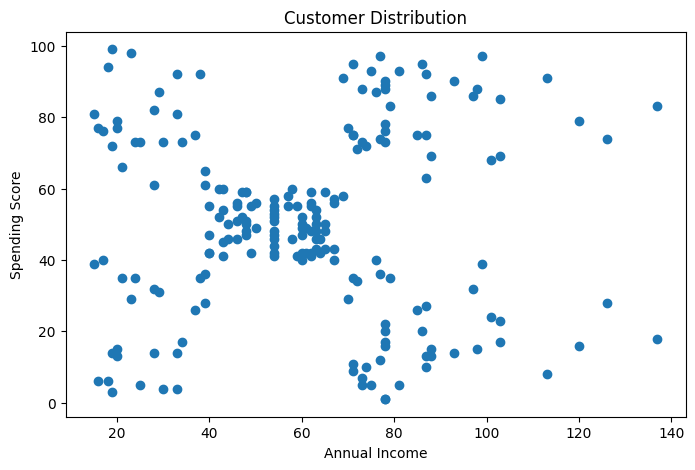

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")

plt.show()

Select Features

In [5]:
X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

Optimal Clusters

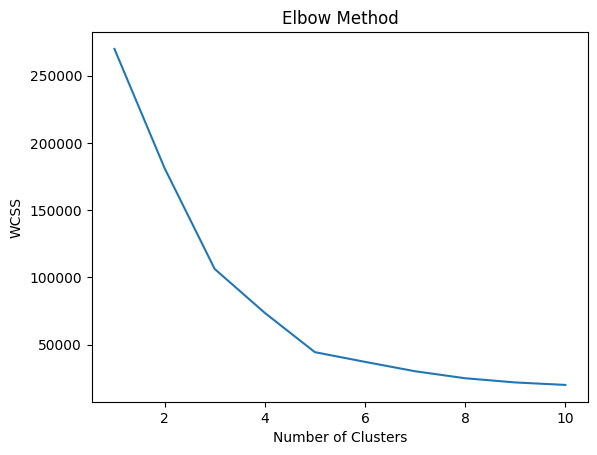

In [6]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

Applying K-Means

In [7]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Visualize Customer Segments

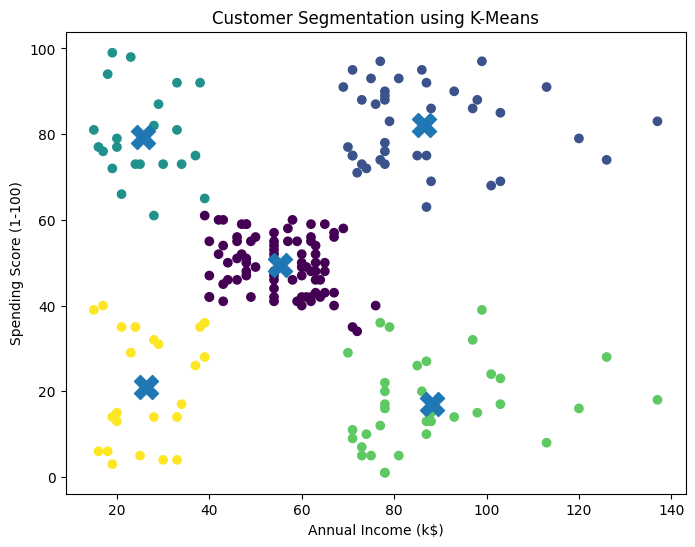

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"]
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker="X"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segmentation using K-Means")

plt.show()

Cluster Distribution Chart

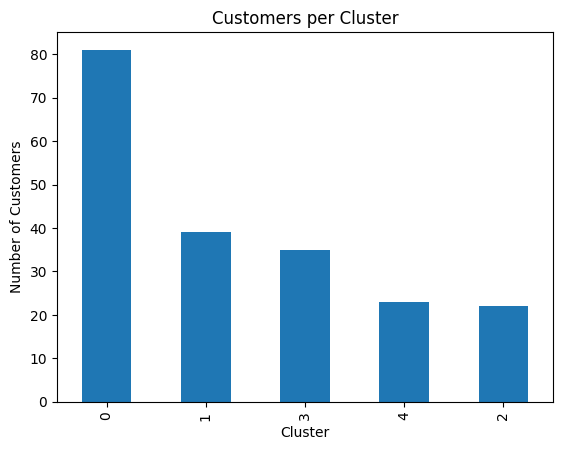

In [12]:
df["Cluster"].value_counts().plot(
    kind="bar"
)

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

Counting Customers in Each Cluster

In [9]:
print(df["Cluster"].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


Cluster Centers

In [10]:
centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=[
        "Annual Income",
        "Spending Score"
    ]
)

print(centers)

   Annual Income  Spending Score
0      55.296296       49.518519
1      86.538462       82.128205
2      25.727273       79.363636
3      88.200000       17.114286
4      26.304348       20.913043


| Cluster | Annual Income | Spending Score | Segment                      |
| ------- | ------------: | -------------: | ---------------------------- |
| 1       |         86.54 |          82.13 | High Value Customers       |
| 3       |         88.20 |          17.11 | High Income, Low Spending |
| 2       |         25.73 |          79.36 | Low Income, High Spending |
| 4       |         26.30 |          20.91 | Low Value Customers       |
| 0       |         55.30 |          49.52 | Average Customers         |


Key Findings

1. Customers were successfully segmented into 5 distinct groups using K-Means clustering.

2. Cluster 1 represents High Value Customers with high income and high spending behavior.

3. Cluster 3 contains customers with high income but low spending, indicating opportunities for targeted marketing campaigns.

4. Cluster 2 includes customers with lower income but high spending behavior, showing strong engagement with products and services.

5. Cluster 4 consists of low-income and low-spending customers who contribute the least revenue.

6. Cluster 0 represents average customers with moderate income and spending levels.

7. Customer segmentation can help businesses personalize marketing strategies and improve customer retention.

Business Recommendations

1. Offer loyalty rewards and premium services to High Value Customers.

2. Create targeted promotions for High Income, Low Spending customers to increase purchases.

3. Develop personalized marketing campaigns for highly engaged customers.

4. Allocate marketing budgets based on customer segment value.

5. Use customer segmentation to improve retention and customer experience.

6. Continuously monitor customer behavior and update segmentation models.